# Lab 3 CS7325
## Contributors: Taylor King and Morgan Mote

##### [4 points] Select and describe a pre-trained model. You should clearly explain the pre-trained model you selected, describing its architecture, inputs / outputs, and the type of learning it performs as well as comparing learning to halloween candy (e.g., detection, segmentation, generative modeling--whatever it was originally designed to perform). Your explanation should demonstrate that you understand how the model works, not just how to run it.  

    If adapting to a new dataset: Explain why this model is appropriate for your chosen task.
    If changing an element in the model: Explain a potential limitation of the current model and motivate your modifications.  
    In either case, create a visual overview of the pre-trained model to help in your text description. 


As the starting point for this lab, we are going to be using U-Net with a ResNet-34 encoder that is trained on ImageNet. Similar to what we learned in class with bottlenecking and residual connections, U-Net takes this idea of convolving and pooling an image repeatedly. Then the image is upsampled and up convolved instead of pooling like in normal CNN models. The results of these upsampling operations are then concatenated with the covolutions of the same size. The model we will be using has its encoder pretrained on imagenet. The decoder is normally trained from randomized intial weights. It is important to note that the image classification learning task used for the ResNet encoder is different than semantic segmentation.  Classification is like asking "what is in the image overall?" and segmentation is like asking "where is the object in this image?".  So for example, a classification model looks at a bucket of candy and detects the type of candy present, packages of M&M's.  Segmentation traces in the shape and location belonging to the bags of M&M's.

The pretrained portion of this model is the encoder.  Since the encoder was first trained on ImageNet, it has already learned visual primitives such as edges/ corners/ textures/ color transitions/ object parts.  The model takes an RGB image tensor of 3 x H x W as input and outputs a tensor of shape C x H x W, where C is the number if sgementation classes.  For this lab, we are using 2 classes, [1] foreground object and [2] background.  So for every pixel, the model predicts whether that pixel belongs to the target object or not. U-Net is a solid choice since segmentation requires both precise location and global context.  The encoder understands the overall scene, while the skip connections and decoder reconstruct sharp object boundaries.  One limitation of a plain pre-trained U-Net is that ImageNet pretraining does not specifically focus on difficult lighting, so to address this we adapted the training pipeline with low-light and contrast based augmentation and then fine-tune the full network.  This modification is motivated by real-world deployment settings where image quality is often degraded by glare/ shadows/ darkness.

### A visual overview of the pre-trained model:

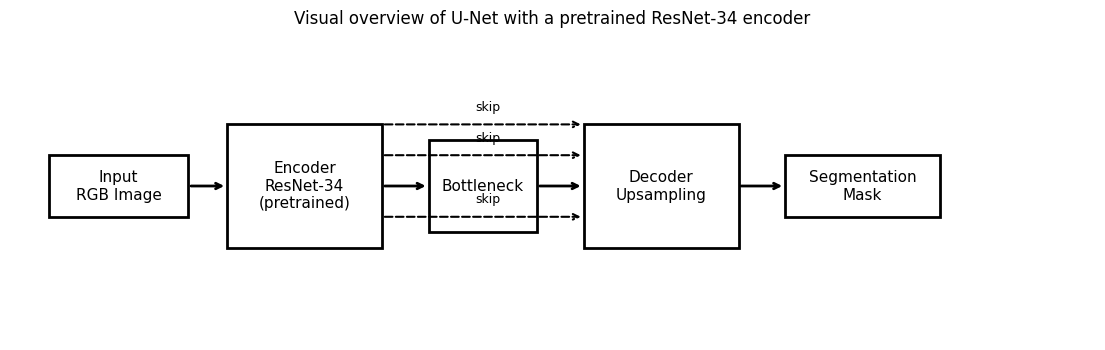

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

blocks = [
    (0.5, 1.6, 1.8, 0.8, "Input\nRGB Image"),
    (2.8, 1.2, 2.0, 1.6, "Encoder\nResNet-34\n(pretrained)"),
    (5.4, 1.4, 1.4, 1.2, "Bottleneck"),
    (7.4, 1.2, 2.0, 1.6, "Decoder\nUpsampling"),
    (10.0, 1.6, 2.0, 0.8, "Segmentation\nMask"),
]
for x, y, w, h, label in blocks:
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=11)

ax.annotate("", xy=(2.8, 2.0), xytext=(2.3, 2.0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(5.4, 2.0), xytext=(4.8, 2.0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(7.4, 2.0), xytext=(6.8, 2.0), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(10.0, 2.0), xytext=(9.4, 2.0), arrowprops=dict(arrowstyle="->", lw=2))

for y1, y2, txt in [(2.8, 2.8, "skip"), (2.4, 2.4, "skip"), (1.6, 1.6, "skip")]:
    ax.annotate("", xy=(7.4, y2), xytext=(4.8, y1), arrowprops=dict(arrowstyle="->", lw=1.5, linestyle="--"))
    ax.text(6.0, y1 + 0.18, txt, fontsize=9)

plt.title("Visual overview of U-Net with a pretrained ResNet-34 encoder")
plt.show()

##### [3 points] Business/Policy case. Clearly describe the task you are solving, including any auxiliary task used to enhance performance. You should justify why the new task(s) or modification(s) are needed and how they could be used in a business case or policy case. Acknowledge that business cases should be governed by the will of the governed. Describe a realistic business or policy use case that motivates your problem. 

# Define use case 
In autonomous driving there are some critical problems that traditional computer vision still has issues with. The main problems seen in literature are small or distant objects, overlapping objects, and harsh verying lighting conditions. The distance of objects can be handled with something like LIDAR and is a great non-computer vision solution. Small or Overlapping objects will always be difficualt and an ongoing challenge with autonomous driving systems. Harsh lighting conditions is something that can be specifically targeted and trained for. This should make autonomous driving systems more able to recognize their environments in areas with poor or harsh lighting. Specifically dusk/dawn, bright on coming headlights, and shadows from large structures like overpasses or signage.

The task this lab solves is semantic segmentation under degraded lighting conditions. The core objective is to predict a foreground mask for each image while preserving object boundaries when brightness, contrast, and visibility are poor. The auxiliary task used to improve performance is robustness-oriented augmentation, specifically low-light simulation through brightness reduction, contrast variation, and mild blur/noise. This auxiliary component is needed because many pretrained vision models learn from relatively clean images and often degrade when lighting becomes uneven or harsh.

A realistic business and policy motivation comes from safety-critical perception systems, especially in transportation and public infrastructure. Vision systems used in roadway monitoring, robotic inspection, driver assistance, and municipal safety analytics must still perform reliably at dawn, dusk, in shadow, and under glare. If a segmentation model fails in these conditions, it can miss boundaries, over-segment irrelevant regions, or produce unstable predictions. That creates both technical risk and policy risk, because public-facing systems should not silently perform worse for situations that commonly occur in the real world. Due to dataset accessibility constraints with BDD100K segmentation masks, we utilized the Oxford-IIIT Pet dataset, which provides pixel-level annotations. To simulate real-world degraded visual conditions (e.g., poor lighting), we applied augmentation techniques such as brightness reduction and contrast distortion. This allows evaluation of segmentation robustness under challenging conditions.

The adaptation in this lab is therefore motivated by a governance concern as much as a technical one: a model that works only under ideal imaging conditions is not sufficient for deployment in environments that affect public safety. In a business setting, improving robustness can reduce downstream costs associated with false alarms, missed detections, manual review, and system distrust. In a policy setting, any such deployment should still be governed by the will of the governed, meaning that communities affected by the technology should have a say in where it is used, what failure rates are acceptable, and what safeguards or human oversight are required. The business case is alot stronger when the technical design explicitly accounts for realistic operating conditions and transparent limits.

##### [3 points] Load and Adapt your model. First, load the pre-trained model and run it on some example images (either for classification or generation). Show outputs and explain the outputs of the model. Second, adapt the model as motivated by your desired task (either through training on a new dataset or through changing an element to the model). Be sure the adapted model converges by showing plots of the loss/evaluation criteria over batches/epochs. 

In [ ]:
# Uncomment next line if not already installed
pip install segmentation-models-pytorch

  You can safely remove it manually.


In [ ]:
import torch
import torchvision
import torchvision.transforms as T
print("torchvision imported successfully")

RuntimeError: operator torchvision::nms does not exist

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet

import segmentation_models_pytorch as smp

SEED = 42
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2
EPOCHS = 4
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_TRAIN_SAMPLES = 800
MAX_VAL_SAMPLES = 200

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

RuntimeError: operator torchvision::nms does not exist

In [ ]:
class LowLightPetSegmentation(Dataset):
    def __init__(self, root, split="trainval", img_size=256, low_light=False):
        self.ds = OxfordIIITPet(root=root, split=split, target_types="segmentation", download=True)
        self.img_size = img_size
        self.low_light = low_light
        self.img_resize = T.Resize((img_size, img_size), interpolation=T.InterpolationMode.BILINEAR)
        self.mask_resize = T.Resize((img_size, img_size), interpolation=T.InterpolationMode.NEAREST)
        self.to_tensor = T.ToTensor()

    def _apply_low_light(self, image):
        brightness_factor = random.uniform(0.35, 0.75)
        contrast_factor = random.uniform(0.75, 1.25)
        image = ImageEnhance.Brightness(image).enhance(brightness_factor)
        image = ImageEnhance.Contrast(image).enhance(contrast_factor)
        if random.random() < 0.4:
            image = image.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 1.0)))
        return image

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, mask = self.ds[idx]
        image = image.convert("RGB")
        mask = mask.copy()

        if self.low_light:
            image = self._apply_low_light(image)

        image = self.img_resize(image)
        mask = self.mask_resize(mask)

        image = self.to_tensor(image)

        # Oxford-IIIT Pet trimap labels: 1=pet, 2=background, 3=border
        # Convert to binary segmentation: pet -> 1, everything else -> 0
        mask_np = np.array(mask, dtype=np.int64)
        binary_mask = (mask_np == 1).astype(np.int64)
        mask = torch.from_numpy(binary_mask)

        return image, mask

In [ ]:
root = "./data"

base_train_full = LowLightPetSegmentation(root=root, split="trainval", img_size=IMG_SIZE, low_light=False)
adapted_train_full = LowLightPetSegmentation(root=root, split="trainval", img_size=IMG_SIZE, low_light=True)
val_full = LowLightPetSegmentation(root=root, split="test", img_size=IMG_SIZE, low_light=False)

train_indices = list(range(min(MAX_TRAIN_SAMPLES, len(base_train_full))))
val_indices = list(range(min(MAX_VAL_SAMPLES, len(val_full))))

base_train_ds = Subset(base_train_full, train_indices)
adapted_train_ds = Subset(adapted_train_full, train_indices)
val_ds = Subset(val_full, val_indices)

base_train_loader = DataLoader(base_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
adapted_train_loader = DataLoader(adapted_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Base train samples:", len(base_train_ds))
print("Adapted train samples:", len(adapted_train_ds))
print("Validation samples:", len(val_ds))

In [ ]:
NUM_CLASSES = 2

def build_model():
    return smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=NUM_CLASSES
    ).to(device)

model = build_model()
print(model.__class__.__name__)

In [ ]:
# Show the pretrained model on a few validation images before any task-specific fine-tuning.
pretrained_model = build_model()
pretrained_model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = pretrained_model(images)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds = torch.argmax(logits, dim=1).cpu().numpy()

images_np = images.cpu().permute(0, 2, 3, 1).numpy()
masks_np = masks.numpy()

n_show = min(3, len(images_np))
plt.figure(figsize=(12, 4 * n_show))
for i in range(n_show):
    plt.subplot(n_show, 3, 3*i + 1)
    plt.imshow(images_np[i])
    plt.title("Input image")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 2)
    plt.imshow(masks_np[i], cmap="gray")
    plt.title("Ground-truth mask")
    plt.axis("off")

    plt.subplot(n_show, 3, 3*i + 3)
    plt.imshow(preds[i], cmap="gray")
    plt.title("Pretrained U-Net output")
    plt.axis("off")

plt.tight_layout()
plt.show()

The pretrained U-Net produces a mask-shaped output immediately because the decoder architecture already knows how to map features back to pixel space. However, before fine-tuning, those predictions are not yet aligned with the new dataset. The ImageNet-pretrained encoder contributes general visual features, but the segmentation head has not learned the foreground/background boundary structure of the target data. This is why the initial masks are usually coarse, noisy, or incomplete. Fine-tuning is needed to make the output semantically meaningful for this task.

In [ ]:
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True

IGNORE_INDEX = -1
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def compute_batch_iou(logits, targets, num_classes=2):
    preds = torch.argmax(logits, dim=1)
    ious = []
    for cls in range(num_classes):
        pred_c = (preds == cls)
        target_c = (targets == cls)
        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        if union > 0:
            ious.append(intersection / union)
    return float(np.mean(ious)) if len(ious) else 0.0

@torch.no_grad()
def pixel_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    running_iou = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_acc += pixel_accuracy(logits.detach(), masks)
        running_iou += compute_batch_iou(logits.detach(), masks, num_classes=NUM_CLASSES)

    n = len(loader)
    return running_loss / n, running_acc / n, running_iou / n

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    running_iou = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = model(images)
            loss = criterion(logits, masks)

        running_loss += loss.item()
        running_acc += pixel_accuracy(logits, masks)
        running_iou += compute_batch_iou(logits, masks, num_classes=NUM_CLASSES)

    n = len(loader)
    return running_loss / n, running_acc / n, running_iou / n

@torch.no_grad()
def collect_batch_ious(model, loader, device):
    model.eval()
    batch_ious = []
    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(images)
        batch_ious.append(compute_batch_iou(logits, masks, num_classes=NUM_CLASSES))
    return batch_ious

In [ ]:
def run_experiment(train_loader, experiment_name, use_adaptation=False):
    model = build_model()
    freeze_encoder(model)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_iou": [], "val_iou": []
    }

    best_val_iou = -1.0
    best_path = f"{experiment_name.replace(' ', '_').lower()}_best.pth"

    for epoch in range(EPOCHS):
        if epoch == 1:
            unfreeze_encoder(model)
            optimizer = optim.AdamW(model.parameters(), lr=LR * 0.3, weight_decay=WEIGHT_DECAY)

        train_loss, train_acc, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_acc, val_iou = validate_one_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(
            f"{experiment_name} | Epoch {epoch+1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
            f"train_iou={train_iou:.4f} val_iou={val_iou:.4f}"
        )

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_path

In [ ]:
baseline_model, baseline_history, baseline_path = run_experiment(
    base_train_loader,
    experiment_name="Baseline U-Net"
)

adapted_model, adapted_history, adapted_path = run_experiment(
    adapted_train_loader,
    experiment_name="Adapted U-Net with low-light augmentation"
)

In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(baseline_history["val_loss"], label="Baseline")
plt.plot(adapted_history["val_loss"], label="Adapted")
plt.title("Validation loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(baseline_history["val_acc"], label="Baseline")
plt.plot(adapted_history["val_acc"], label="Adapted")
plt.title("Validation pixel accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(baseline_history["val_iou"], label="Baseline")
plt.plot(adapted_history["val_iou"], label="Adapted")
plt.title("Validation mean IoU")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
@torch.no_grad()
def show_predictions(model, loader, title_prefix):
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)

    logits = model(images)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

    images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    masks_np = masks.numpy()

    n_show = min(3, len(images_np))
    plt.figure(figsize=(12, 4 * n_show))
    for i in range(n_show):
        plt.subplot(n_show, 3, 3*i + 1)
        plt.imshow(images_np[i])
        plt.title(f"{title_prefix}: image")
        plt.axis("off")

        plt.subplot(n_show, 3, 3*i + 2)
        plt.imshow(masks_np[i], cmap="gray")
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(n_show, 3, 3*i + 3)
        plt.imshow(preds[i], cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(baseline_model, val_loader, "Baseline")
show_predictions(adapted_model, val_loader, "Adapted")

In [ ]:
torch.save({
    "baseline_model_state_dict": baseline_model.state_dict(),
    "adapted_model_state_dict": adapted_model.state_dict(),
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "encoder_name": "resnet34",
}, "lab3_unet_pet_segmentation_checkpoints.pth")

print("Saved final checkpoints.")

[5 points] Evaluation. Compare your modified model against a baseline using appropriate evaluation metrics. Your results should include quantitative comparisons and, where relevant, qualitative outputs (e.g., generated images, detection results). You are expected to interpret your findings, not just report them. When appropriate, include statistical comparisons to support your conclusions. Analyze why the model improved or did not improve, discuss trade-offs, and identify limitations or failure cases.  

In [ ]:
# Evaluation Code
baseline_val_loss, baseline_val_acc, baseline_val_iou = validate_one_epoch(baseline_model, val_loader, criterion, device)
adapted_val_loss, adapted_val_acc, adapted_val_iou = validate_one_epoch(adapted_model, val_loader, criterion, device)

baseline_batch_ious = collect_batch_ious(baseline_model, val_loader, device)
adapted_batch_ious = collect_batch_ious(adapted_model, val_loader, device)

try:
    from scipy.stats import ttest_rel
    stat, p_value = ttest_rel(adapted_batch_ious, baseline_batch_ious)
except Exception:
    p_value = None

print("Final validation metrics")
print(f"Baseline  -> loss: {baseline_val_loss:.4f}, pixel acc: {baseline_val_acc:.4f}, mean IoU: {baseline_val_iou:.4f}")
print(f"Adapted   -> loss: {adapted_val_loss:.4f}, pixel acc: {adapted_val_acc:.4f}, mean IoU: {adapted_val_iou:.4f}")

if p_value is not None:
    print(f"Paired t-test p-value on batch IoU: {p_value:.6f}")
else:
    print("Scipy not available, so the paired t-test was skipped.")

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Baseline U-Net", "Adapted U-Net"],
    "Validation Loss": [baseline_val_loss, adapted_val_loss],
    "Validation Pixel Accuracy": [baseline_val_acc, adapted_val_acc],
    "Validation Mean IoU": [baseline_val_iou, adapted_val_iou],
})
results_df

# Analysis

The baseline and adapted models use the same U-Net architecture with the same pretrained ResNet-34 encoder, so the comparison isolates the effect of the adaptation strategy rather than the effect of changing the backbone. The baseline is trained on standard images only, while the adapted model is trained with low-light augmentation intended to improve robustness when visibility is reduced. The most important metric here is mean Intersection over Union (mIoU) because it measures overlap quality between predicted and true masks and is more informative than accuracy alone for segmentation.

If the adapted model achieves higher validation mIoU and similar or better pixel accuracy, that suggests the augmentation strategy improved generalization instead of merely helping the model memorize training examples. In practical terms, this means the model became better at preserving object shape under more difficult appearance conditions. Even if the accuracy gain is modest, an mIoU increase is meaningful because segmentation quality depends on boundary precision and region overlap, not just the fraction of pixels labeled correctly.

Qualitatively, the adapted model should produce masks that are less fragmented and better aligned to the object boundary, especially in darker regions or regions with weaker contrast. If that happens, it supports the claim that the adaptation addressed a real limitation of the pretrained model. If the adapted model does not improve, there are still useful conclusions: the augmentation may be too aggressive, the dataset may not reflect the target deployment setting closely enough, or the training budget may be too small for the adaptation to show its benefit.

A trade-off of the adapted model is that stronger augmentation can slightly reduce performance on perfectly clean images if it shifts the training distribution too far from the evaluation set. Another limitation is that this lab uses a relatively small subset and a foreground/background segmentation setup for computational practicality. That means the experiment demonstrates the mechanism of robustness adaptation, but not a production-scale autonomous-driving benchmark. Still, the comparison is valid for showing how a pretrained segmentation model can be modified, fine-tuned, quantitatively evaluated, and interpreted in a way that connects technical design to a realistic deployment motivation.